In [15]:
# Scikit learn
# pip install scikit-learn
import sklearn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv(r'C:\xampp816\htdocs\personal-dev\py-ds\ML\KNN\heart_model\heart.csv')
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [16]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [17]:
df.shape

(1025, 14)

In [18]:
column_to_handle_zero_values = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
for col in column_to_handle_zero_values:
    print(col)
    print(df[df[col]==0])
    print('\n\n\n')

age
Empty DataFrame
Columns: [age, sex, cp, trestbps, chol, fbs, restecg, thalach, exang, oldpeak, slope, ca, thal, target]
Index: []




trestbps
Empty DataFrame
Columns: [age, sex, cp, trestbps, chol, fbs, restecg, thalach, exang, oldpeak, slope, ca, thal, target]
Index: []




chol
Empty DataFrame
Columns: [age, sex, cp, trestbps, chol, fbs, restecg, thalach, exang, oldpeak, slope, ca, thal, target]
Index: []




thalach
Empty DataFrame
Columns: [age, sex, cp, trestbps, chol, fbs, restecg, thalach, exang, oldpeak, slope, ca, thal, target]
Index: []




oldpeak
      age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  \
3      61    1   0       148   203    0        1      161      0      0.0   
19     58    1   2       140   211    1        0      165      0      0.0   
23     63    0   2       135   252    0        0      172      0      0.0   
24     42    0   2       120   209    0        1      173      0      0.0   
27     58    0   1       136   319    1      

In [19]:
df.duplicated().sum()

np.int64(723)

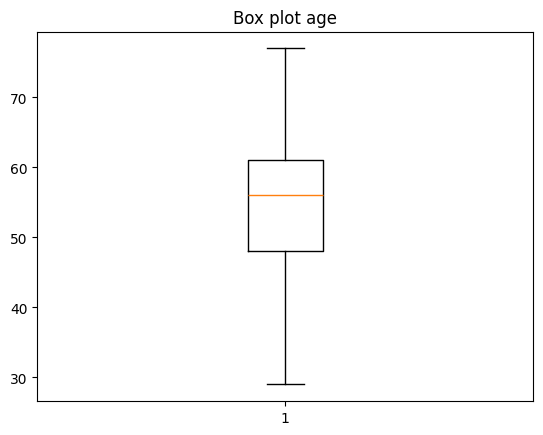

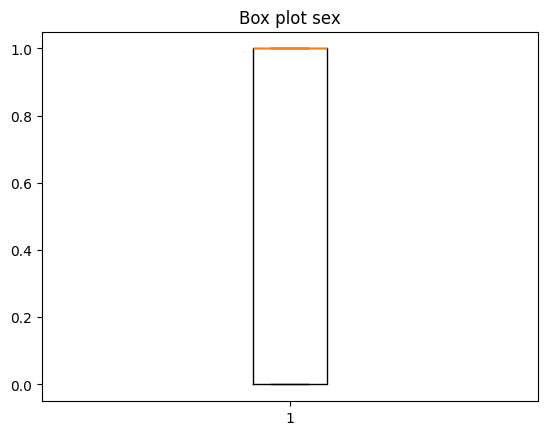

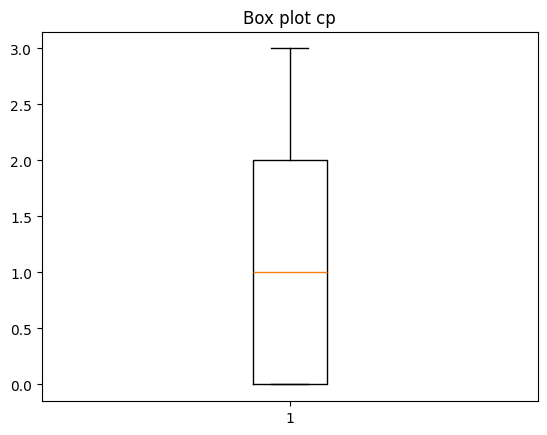

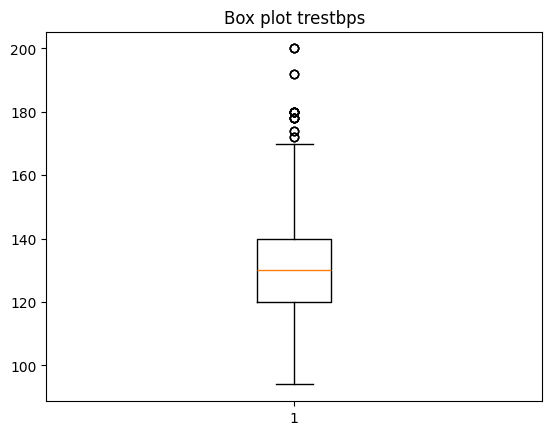

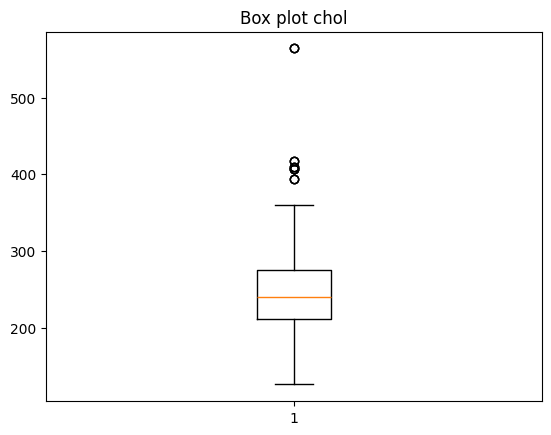

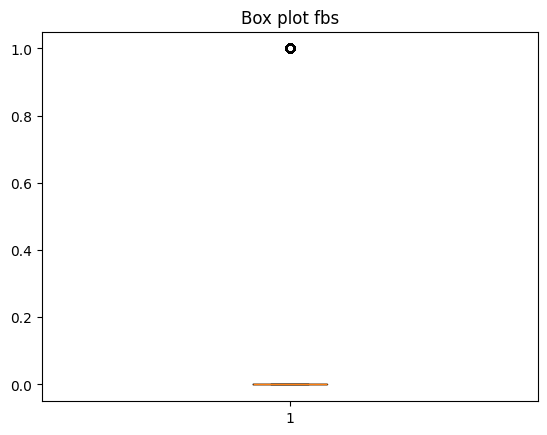

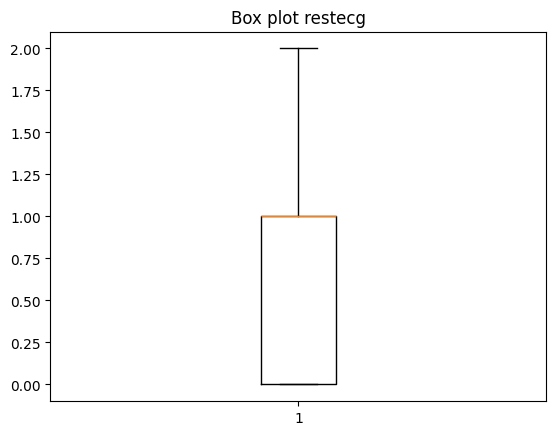

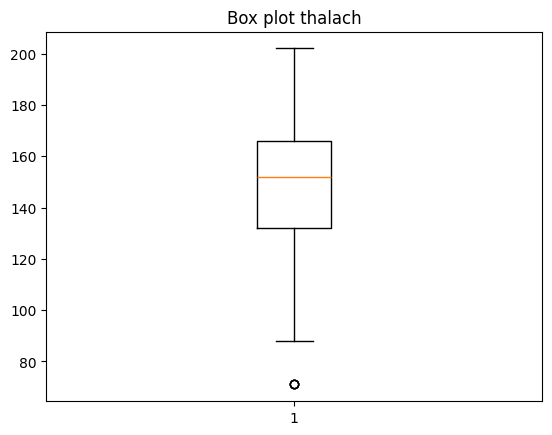

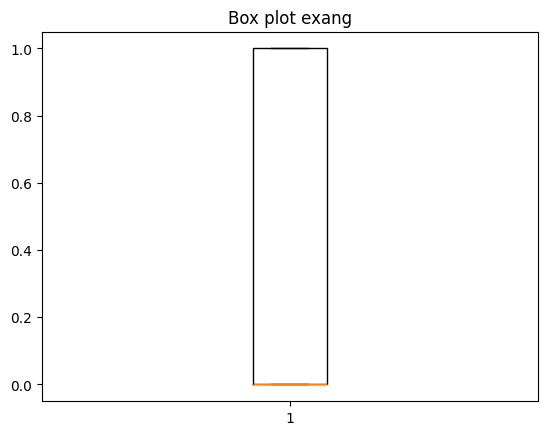

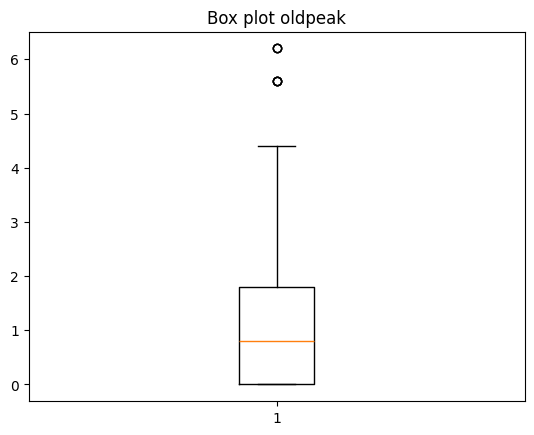

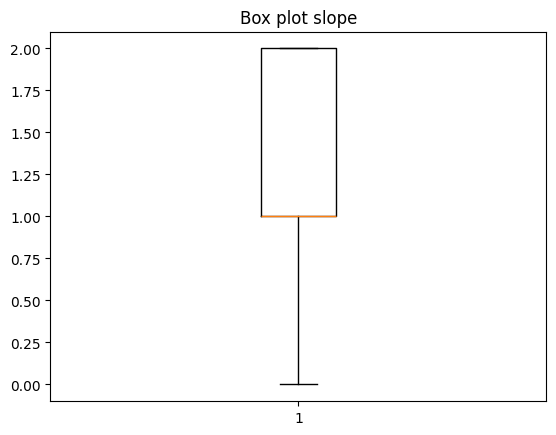

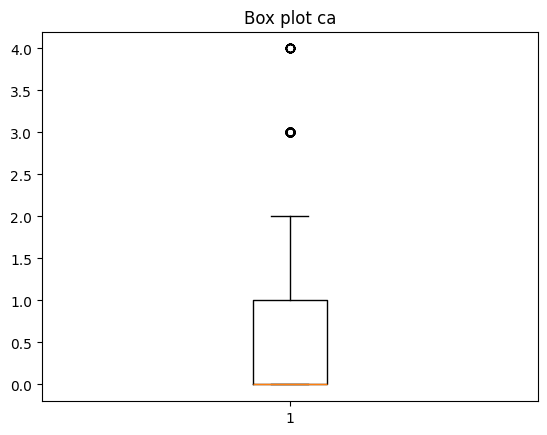

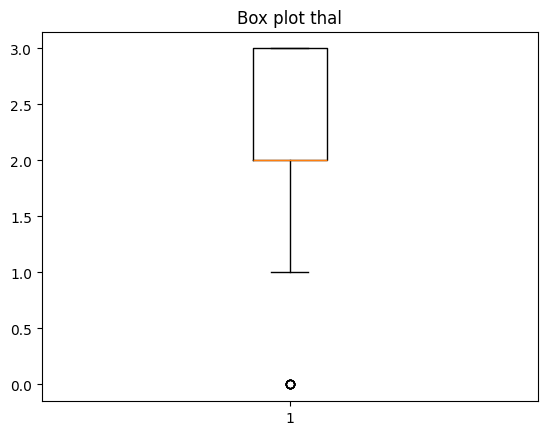

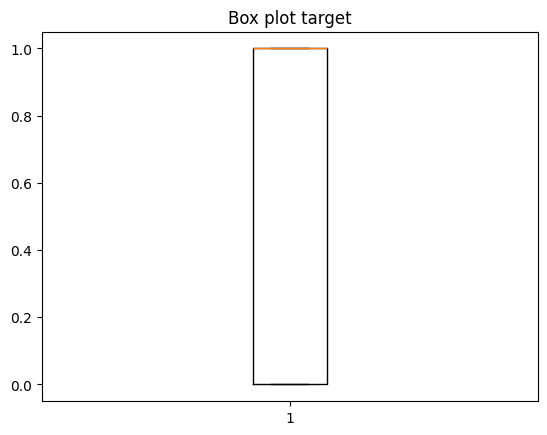

In [20]:
for i in df:
    if df[i].dtype=='int64' or df[i].dtype=='float':
        plt.boxplot(df[i])
        plt.title(f'Box plot {i}')
        plt.show()

In [21]:
dict1={}
for i in df:
    if df[i].dtype=='int64' or df[i].dtype=='float':
        q1=df[i].quantile(0.25)
        q3=df[i].quantile(0.75)
        iqr=q3-q1
        min_range=q1-1.5*iqr
        max_range=q3+1.5*iqr
        dict1[i]=(min_range,max_range)
        # df=df[(df[i]>=min_range) & (df[i]<=max_range) ]
dict1

{'age': (np.float64(28.5), np.float64(80.5)),
 'sex': (np.float64(-1.5), np.float64(2.5)),
 'cp': (np.float64(-3.0), np.float64(5.0)),
 'trestbps': (np.float64(90.0), np.float64(170.0)),
 'chol': (np.float64(115.0), np.float64(371.0)),
 'fbs': (np.float64(0.0), np.float64(0.0)),
 'restecg': (np.float64(-1.5), np.float64(2.5)),
 'thalach': (np.float64(81.0), np.float64(217.0)),
 'exang': (np.float64(-1.5), np.float64(2.5)),
 'oldpeak': (np.float64(-2.7), np.float64(4.5)),
 'slope': (np.float64(-0.5), np.float64(3.5)),
 'ca': (np.float64(-1.5), np.float64(2.5)),
 'thal': (np.float64(0.5), np.float64(4.5)),
 'target': (np.float64(-1.5), np.float64(2.5))}

In [22]:
# print(df[df['Insulin']>=135.875])
# column_to_handle_outlier_values = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
# for i in column_to_handle_outlier_values:
#     print(df[df[i]<=dict1[i][1]]['target'].value_counts())
# print(df[df['Insulin']>=135.875]['Outcome'].value_counts())

print(df[df['age']>=80.5]['target'].value_counts())
print(df[df['trestbps']>=170.0]['target'].value_counts())
print(df[df['chol']>=371.0]['target'].value_counts())
print(df[df['thalach']>=217.0]['target'].value_counts())
print(df[df['oldpeak']>=4.5]['target'].value_counts())

Series([], Name: count, dtype: int64)
target
0    32
1    13
Name: count, dtype: int64
target
1    9
0    7
Name: count, dtype: int64
Series([], Name: count, dtype: int64)
target
0    7
Name: count, dtype: int64


In [23]:
x=df.drop(columns=['target'])
y=df['target']

In [24]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler
minmax=MinMaxScaler()
x_scaled=minmax.fit_transform(x)

In [25]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x_scaled,y,test_size=0.3,random_state=5)

In [26]:
from sklearn.neighbors import KNeighborsClassifier
# from sklearn.neighbors import KNeighborsRegressor
model=KNeighborsClassifier()
# model=KNeighborsRegressor()
model.fit(x_train, y_train)

KNeighborsClassifier()

In [27]:
y_pred=model.predict(x_test)
y_pred

array([1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1,
       0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0,
       1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0,
       0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0,
       1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1,
       0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1,
       0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1,
       1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0,
       0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1,
       0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1,
       1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1,
       1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0,

In [28]:
from sklearn.metrics import accuracy_score
print(accuracy_score(y_test, y_pred)*100)

86.03896103896103
